# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

Diabetes Dataset:
   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       0.0        1.0  26.0     0.0     0.0   
1              0.0     1.0       1.0        1.0  26.0     1.0     1.0   
2              0.0     0.0       0.0        1.0  26.0     0.0     0.0   
3              0.0     1.0       1.0        1.0  28.0     1.0     0.0   
4              0.0     0.0       0.0        1.0  29.0     1.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           1.0     0.0  ...            1.0   
1                   0.0           0.0     1.0  ...            1.0   
2                   0.0           1.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      3.0       5.0      30.0      

Text(0, 0.5, 'Second Principal Component Score')

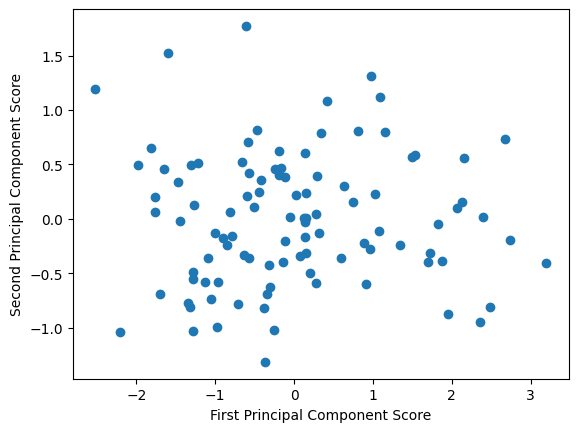

In [6]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
from sklearn import decomposition
from sklearn import linear_model
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])


df_diabetes = pd.read_csv("diabetes_dataset.csv")
df_kidney = pd.read_csv("Kidney_dataset.csv")
df_hypertension = pd.read_csv("hypertension_dataset.csv")

print("Diabetes Dataset:")
print(df_diabetes.head(), "\n")

print("Kidney Dataset:")
print(df_kidney.head(), "\n")

print("Hypertension Dataset:")
print(df_hypertension.head(), "\n")

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

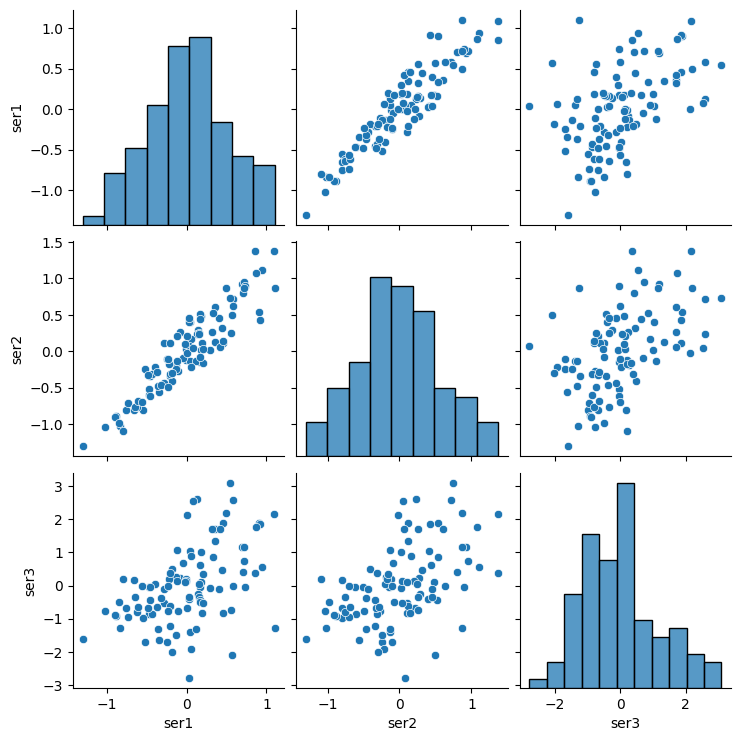

In [7]:
import seaborn as sns

#copied from above
np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores


sns.pairplot(df)

## **Answer**

The outliers are located in the upper left corner which means the first PC Score is low(left side) and the second PC score is high(upper/top area). PC1 captures the most dominant variance pattern, here looks to be series 1 and 2. It is hard to say anything about series 1 and 2 together and individually bc they are highly correlated. They have similar values in the PC1 vector and this mostly reflects overall size together rather than individual differences. The pairplot shows a stong linear relationship between series 1 and 2 and more scatter for those involving series 3. Since the outliers have a low first PC and a hig second PC this means they deviate strongly in series 3. 

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

## Diabetes Dataset

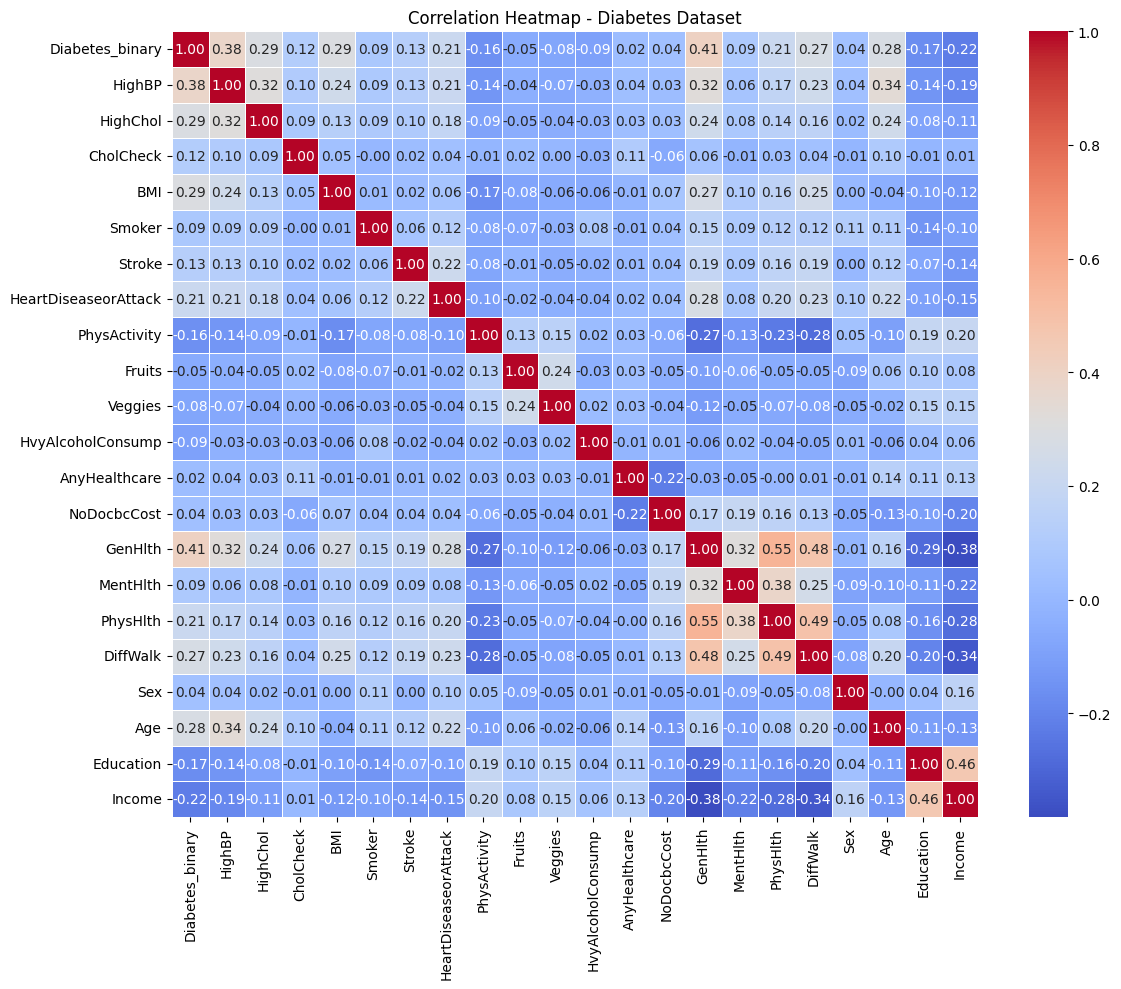

In [8]:

corr_diabetes = df_diabetes.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_diabetes, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap - Diabetes Dataset')
plt.tight_layout()
plt.show()

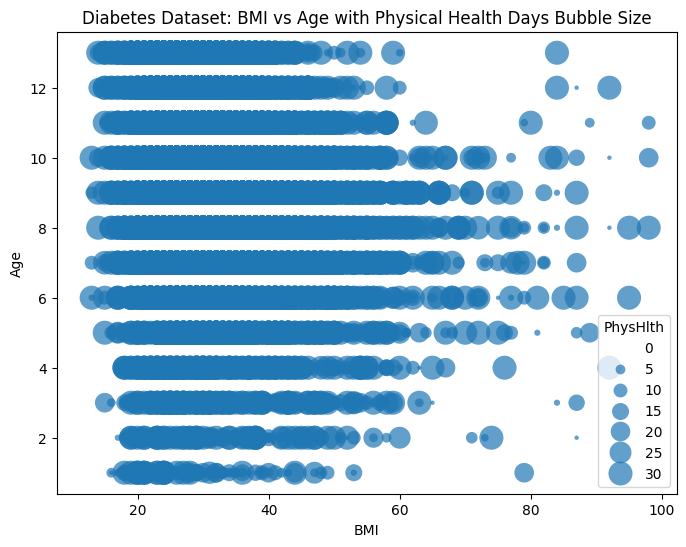

In [9]:
min_phys = df_diabetes['PhysHlth'].min()
max_phys = df_diabetes['PhysHlth'].max()
max_bubble = 300

plt.figure(figsize=(8,6))
ax = sns.scatterplot(
    data=df_diabetes,
    x='BMI',
    y='Age',
    size='PhysHlth',
    sizes=(min_phys / max_phys * max_bubble, max_bubble),
    alpha=0.7,
    edgecolor='k'
)
ax.set_xlabel("BMI")
ax.set_ylabel("Age")
ax.set_title("Diabetes Dataset: BMI vs Age with Physical Health Days Bubble Size")
plt.show()

In [10]:
diabetes_numeric_cols = [
    'BMI', 'Age', 'Income', 'PhysHlth', 'MentHlth', 'DiffWalk'
]

df_diabetes_num = df_diabetes[diabetes_numeric_cols].dropna()

# Fit PCA with 1 component
pca_diabetes = decomposition.PCA(n_components=1)
pca_diabetes.fit(df_diabetes_num)

print(f"\nDiabetes dataset:")
print(f"The first principal component explains {pca_diabetes.explained_variance_ratio_[0]:.2%} of the variance")

components = pca_diabetes.components_[0]
means = df_diabetes_num.mean().values

print(f"The components_ vector is {components}")

formula_terms = " + ".join(
    [f"{components[i]:.2f} * ({col} - {means[i]:.2f})" for i, col in enumerate(diabetes_numeric_cols)]
)
print(f"Projection onto PC1 (v) = {formula_terms}")

df_example = df_diabetes_num.copy()
df_example['v'] = np.dot(df_diabetes_num - means, components)

for i, col in enumerate(diabetes_numeric_cols):
    df_example[f'{col}_est'] = df_example['v'] * components[i] + means[i]

print("Examples (first 5 rows showing original and approximated data):")
print(df_example[[*diabetes_numeric_cols, *[f'{c}_est' for c in diabetes_numeric_cols]]].head())

print("Means used for centering:")
for col, mu in zip(diabetes_numeric_cols, means):
    print(f"{col}: {mu:.3f}")


Diabetes dataset:
The first principal component explains 52.94% of the variance
The components_ vector is [ 0.18017778  0.00702308 -0.06337826  0.84686761  0.49588048  0.01968874]
Projection onto PC1 (v) = 0.18 * (BMI - 29.86) + 0.01 * (Age - 8.58) + -0.06 * (Income - 5.70) + 0.85 * (PhysHlth - 5.81) + 0.50 * (MentHlth - 3.75) + 0.02 * (DiffWalk - 0.25)
Examples (first 5 rows showing original and approximated data):
    BMI   Age  Income  PhysHlth  MentHlth  DiffWalk    BMI_est   Age_est  \
0  26.0   4.0     8.0      30.0       5.0       0.0  33.501301  8.726105   
1  26.0  12.0     8.0       0.0       0.0       0.0  28.487090  8.530658   
2  26.0  13.0     8.0      10.0       0.0       0.0  30.014222  8.590184   
3  28.0  11.0     8.0       3.0       0.0       0.0  29.008513  8.550982   
4  29.0   8.0     8.0       0.0       0.0       0.0  28.579420  8.534257   

   Income_est  PhysHlth_est  MentHlth_est  DiffWalk_est  
0    4.416408     22.939351     13.781827      0.650959  
1    6

In [11]:
features = ['BMI', 'Age', 'HighBP', 'HighChol', 'Smoker']
target = 'Diabetes_binary'

X = df_diabetes[features]
y = df_diabetes[target]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("R^2 on full dataset:", r2_score(y, y_pred))
print("Coefficients:", dict(zip(features, model.coef_)))
print("Intercept:", model.intercept_)

R^2 on full dataset: 0.24387154764986319
Coefficients: {'BMI': np.float64(0.01603053778797675), 'Age': np.float64(0.03075434346225639), 'HighBP': np.float64(0.22031967313863793), 'HighChol': np.float64(0.1451126349456061), 'Smoker': np.float64(0.032265269928920946)}
Intercept: -0.4583824324017862


## Diabetes Conclusions

heatmap: visualizes how numeric features relate. strong correlation between BMI, high BP and diabetes indicate those factors are associated with higher risk. 
bubble plot: BMI and age cluster w physical health. Higher BMI and higher age report more physical health issues. BMI/age are associated in risk. 

Age and BMI are linked to high risk of diabetes, high BP also plays a role. No Extreme outliers, cosnsistent w medical knowledge and hypothesis. 

## Hypertension Dataset

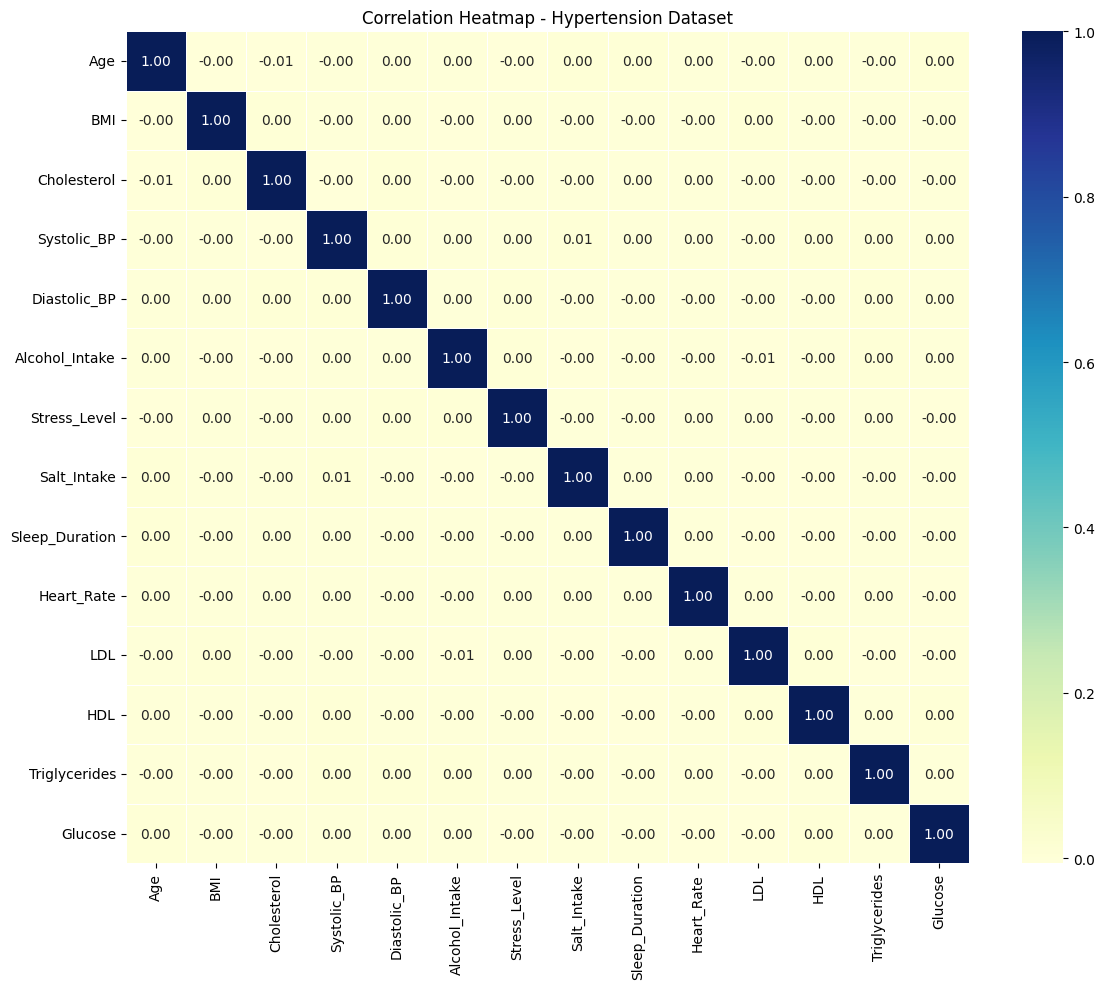

In [ ]:
corr_hypertension = df_hypertension.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_hypertension, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap - Hypertension Dataset')
plt.tight_layout()
plt.show()

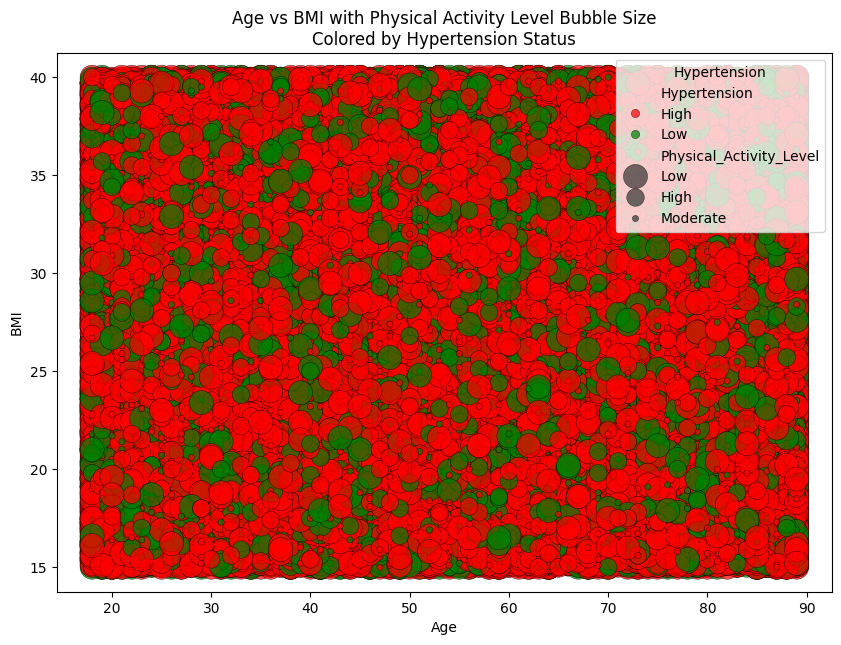

In [24]:
plt.figure(figsize=(10, 7))
ax = sns.scatterplot(
    data=df_hypertension,
    x='Age',
    y='BMI',
    size='Physical_Activity_Level',
    sizes=(20, 300),
    hue='Hypertension', 
    palette={'Low': 'green', 'High': 'red'},
    alpha=0.7,
    edgecolor='k'
)
ax.set_xlabel("Age")
ax.set_ylabel("BMI")
ax.set_title("Age vs BMI with Physical Activity Level Bubble Size\nColored by Hypertension Status")
plt.legend(title='Hypertension')
plt.show()

In [25]:
hypertension_numeric_cols = [
    'Age', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'LDL', 'HDL',
    'Triglycerides', 'Glucose', 'Heart_Rate', 'Salt_Intake', 'Stress_Level'
]

df_hyper_num = df_hypertension[hypertension_numeric_cols].dropna()

pca_hyper = decomposition.PCA(n_components=1)
pca_hyper.fit(df_hyper_num)

print(f"Hypertension dataset:")
print(f"The first principal component explains {pca_hyper.explained_variance_ratio_[0]:.2%} of the variance")

components = pca_hyper.components_[0]
means = df_hyper_num.mean().values

print(f"The components_ vector is {components}")

formula_terms = " + ".join(
    [f"{components[i]:.2f} * ({col} - {means[i]:.2f})" for i, col in enumerate(hypertension_numeric_cols)]
)
print(f"Projection onto PC1 (v) = {formula_terms}")

df_example = df_hyper_num.copy()
df_example['v'] = np.dot(df_hyper_num - means, components)

for i, col in enumerate(hypertension_numeric_cols):
    df_example[f'{col}_est'] = df_example['v'] * components[i] + means[i]

print("Examples (first 5 rows showing original and approximated data):")
print(df_example[[*hypertension_numeric_cols, *[f'{c}_est' for c in hypertension_numeric_cols]]].head())

print("Means used for centering:")
for col, mu in zip(hypertension_numeric_cols, means):
    print(f"{col}: {mu:.3f}")

Hypertension dataset:
The first principal component explains 41.49% of the variance
The components_ vector is [-8.62159760e-05 -2.51012783e-04  1.84748285e-03  6.05972411e-04
 -4.27590300e-03  6.49147633e-04  9.99988623e-01  4.26960054e-04
  7.65029830e-05 -7.45513469e-05  7.03140361e-05]
Projection onto PC1 (v) = -0.00 * (Age - 53.49) + -0.00 * (BMI - 27.49) + 0.00 * (Systolic_BP - 134.51) + 0.00 * (Diastolic_BP - 89.45) + -0.00 * (LDL - 129.53) + 0.00 * (HDL - 64.57) + 1.00 * (Triglycerides - 149.57) + 0.00 * (Glucose - 134.49) + 0.00 * (Heart_Rate - 74.50) + -0.00 * (Salt_Intake - 8.48) + 0.00 * (Stress_Level - 5.01)
Examples (first 5 rows showing original and approximated data):
   Age   BMI  Systolic_BP  Diastolic_BP  LDL  HDL  Triglycerides  Glucose  \
0   58  29.5          160            79  100   75             72      179   
1   34  36.2          120            84   77   47             90      113   
2   73  18.2          156            60  162   56             81      101   


In [ ]:
df_hypertension['Hypertension'] = df_hypertension['Hypertension'].map({'Low': 0, 'High': 1})
features_htn = ['Age', 'BMI', 'Cholesterol', 'Smoking_Status', 'Alcohol_Intake', 'Physical_Activity_Level', 'Stress_Level']
target_htn = 'Hypertension'

df_htn_subset = df_hypertension[features_htn + [target_htn]]

df_htn_encoded = pd.get_dummies(df_htn_subset, drop_first=True)

X_htn = df_htn_encoded.drop(columns=[target_htn])
y_htn = df_htn_encoded[target_htn]

model_htn = LinearRegression()
model_htn.fit(X_htn, y_htn)

y_pred_htn = model_htn.predict(X_htn)

print("Hypertension Prediction R^2:", r2_score(y_htn, y_pred_htn))
print("Coefficients (Hypertension):", dict(zip(X_htn.columns, model_htn.coef_)))
print("Intercept (Hypertension):", model_htn.intercept_)

Hypertension Prediction R^2: 5.486927033648836e-05
Coefficients (Hypertension): {'Age': np.float64(-7.263475187538304e-05), 'BMI': np.float64(-6.347185710071144e-05), 'Cholesterol': np.float64(-4.2109049258787776e-05), 'Alcohol_Intake': np.float64(-0.00010767491840817477), 'Stress_Level': np.float64(-8.228714129243314e-05), 'Smoking_Status_Former': np.float64(-0.00043447407778713), 'Smoking_Status_Never': np.float64(0.002665442361352601), 'Physical_Activity_Level_Low': np.float64(0.003012724289065045), 'Physical_Activity_Level_Moderate': np.float64(0.0036784811658003964)}
Intercept (Hypertension): 0.7329706134939374


## Hypertension Conclusions
heatmap: strong correlations between systolic BP and diastolic BP. Stress level and physical activity show moderate correlations w these BP variables. Suggests these factors play a role in hypertension risk. 
Bubble plot: individuals w high hypertension tend to be older with higher BMI. Age BMI and physical activity are important lifestyle factors associated w hypertension. 
PCA: age, BMI, Systolic BP and stress contribute most to the variance . 
Linear regression: positive coefficients for features age, BMI, cholesterol, stress indicate increases in association to high hypertension risk. 

Age, BMI, physical activity, stress, cholesterol are key demographic and lifestyle factors that contribute to high risk of hypertenstion. 

## Kidney Dataset

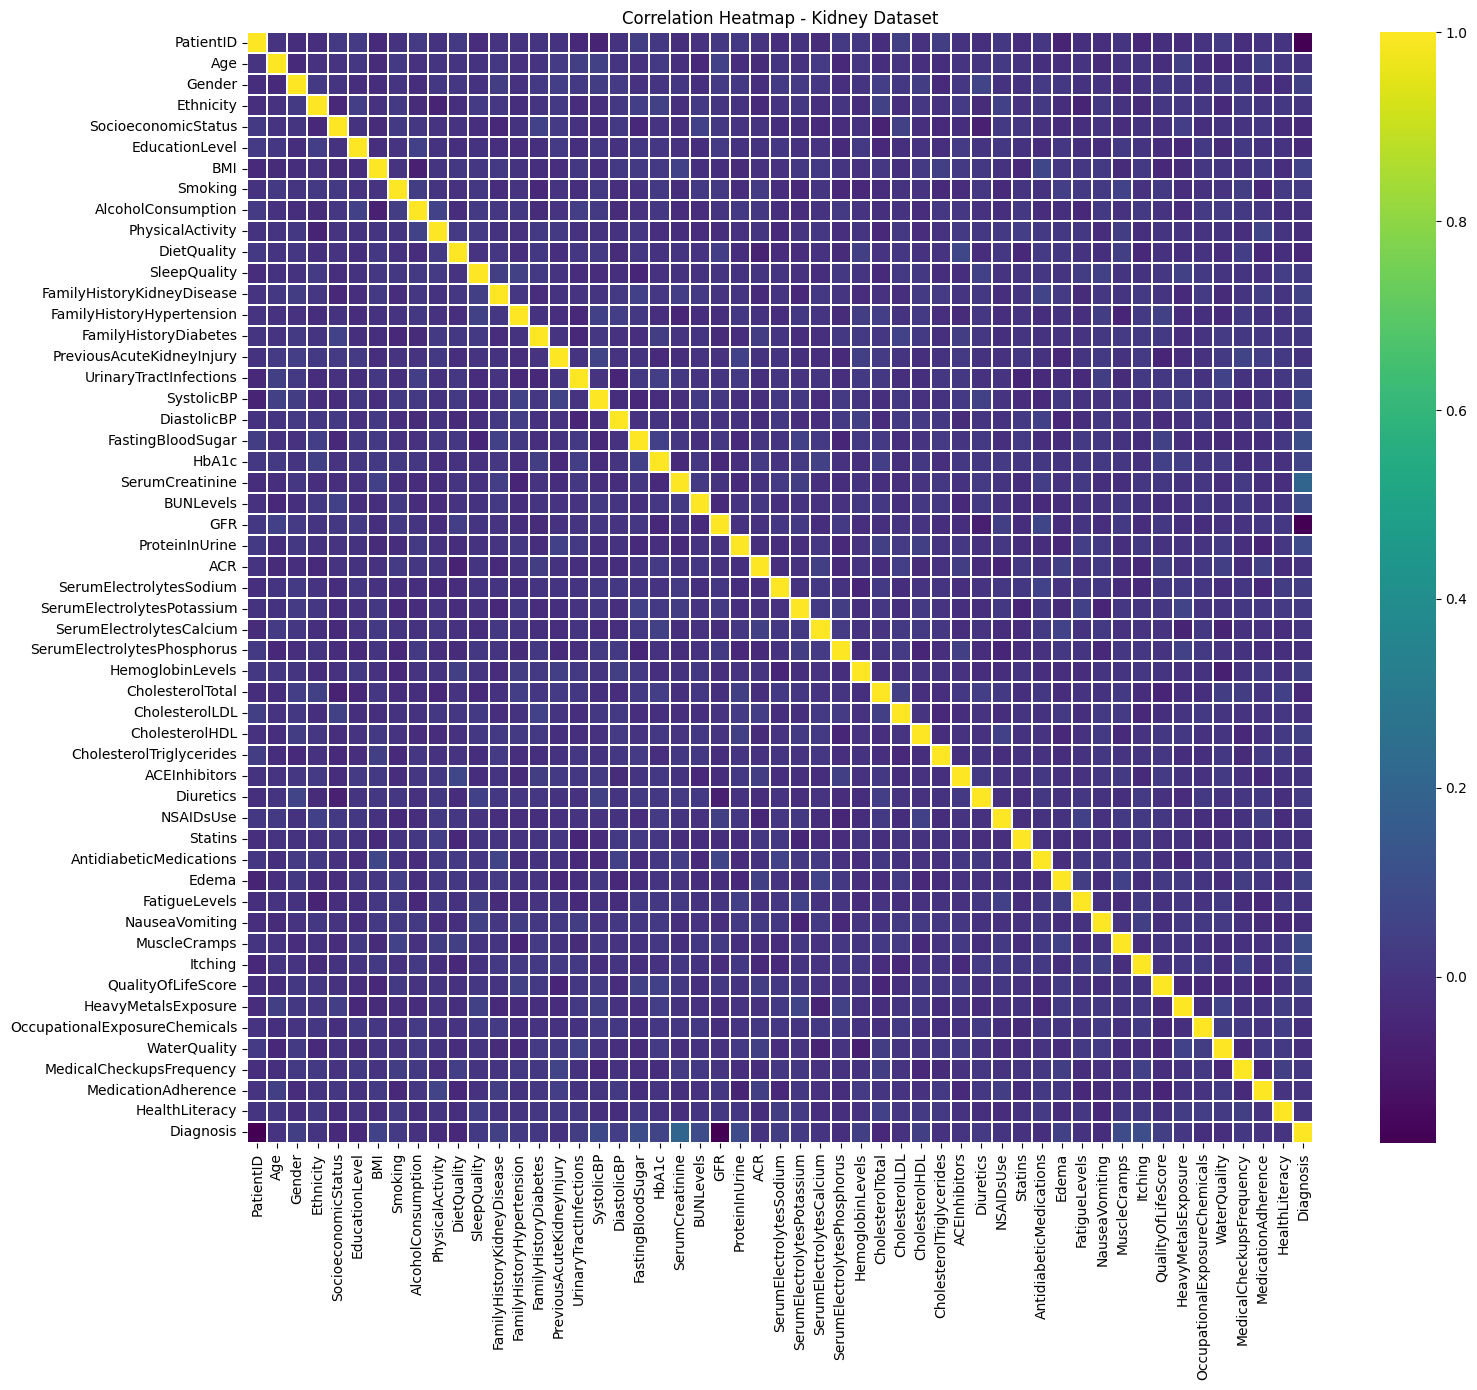

In [ ]:
corr_kidney = df_kidney.corr(numeric_only=True)

plt.figure(figsize=(16, 14))
sns.heatmap(corr_kidney, annot=False, cmap='viridis', linewidths=0.3)
plt.title('Correlation Heatmap - Kidney Dataset')
plt.tight_layout()
plt.show()

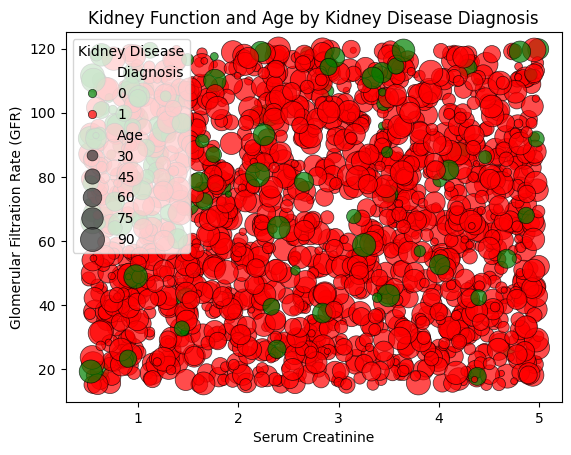

In [ ]:
ax = sns.scatterplot(
    data=df_kidney,
    x='SerumCreatinine',
    y='GFR',
    size='Age',
    hue='Diagnosis',
    sizes=(20, 300),
    palette={0: 'green', 1: 'red'},
    alpha=0.7,
    edgecolor='k'
)

ax.set_xlabel("Serum Creatinine")
ax.set_ylabel("Glomerular Filtration Rate (GFR)")
ax.set_title("Kidney Function and Age by Kidney Disease Diagnosis")

plt.legend(title='Kidney Disease')
plt.show()

In [27]:
numeric_cols = [
    'Age', 'BMI', 'SerumCreatinine', 'GFR', 'SystolicBP', 'DiastolicBP',
    'FastingBloodSugar', 'HbA1c', 'BUNLevels', 'ProteinInUrine'
]

df_num = df_kidney[numeric_cols].dropna()

pca = decomposition.PCA(n_components=1)
pca.fit(df_num)

print(f"The first principal component explains {pca.explained_variance_ratio_[0]:.2%} of the variance")

components = pca.components_[0]
means = df_num.mean().values

print(f"The components_ vector is {components}")

formula_terms = " + ".join(
    [f"{components[i]:.2f} * ({col} - {means[i]:.2f})" for i, col in enumerate(numeric_cols)]
)

print(f"Projection onto PC1 (v) = {formula_terms}")

df_example = df_num.copy()
df_example['v'] = np.dot(df_num - means, components)

for i, col in enumerate(numeric_cols):
    df_example[f'{col}_est'] = df_example['v'] * components[i] + means[i]

print("Examples (first 5 rows showing original and approximated data):")
print(df_example[[*numeric_cols, *[f'{c}_est' for c in numeric_cols]]].head())

print("Means used for centering:")
for col, mu in zip(numeric_cols, means):
    print(f"{col}: {mu:.3f}")

The first principal component explains 34.79% of the variance
The components_ vector is [-6.85744339e-03  4.84568802e-03  4.65452176e-04  1.91936494e-02
 -6.52658511e-02 -3.61469549e-03  9.97621413e-01  2.17541290e-03
 -5.73620712e-03 -1.43658721e-03]
Projection onto PC1 (v) = -0.01 * (Age - 54.44) + 0.00 * (BMI - 27.62) + 0.00 * (SerumCreatinine - 2.75) + 0.02 * (GFR - 66.83) + -0.07 * (SystolicBP - 134.39) + -0.00 * (DiastolicBP - 89.31) + 1.00 * (FastingBloodSugar - 132.53) + 0.00 * (HbA1c - 6.98) + -0.01 * (BUNLevels - 27.58) + -0.00 * (ProteinInUrine - 2.49)
Examples (first 5 rows showing original and approximated data):
   Age        BMI  SerumCreatinine        GFR  SystolicBP  DiastolicBP  \
0   71  31.069414         4.962531  45.703204         113           83   
1   34  29.692119         3.156799  55.784504         120           67   
2   80  37.394822         3.698236  67.559032         147          106   
3   40  31.329680         2.868468  33.202542         117           65

In [ ]:
features_kidney = ['Age', 'BMI', 'SystolicBP', 'DiastolicBP', 'SerumCreatinine', 'BUNLevels', 'ProteinInUrine']
target_kidney = 'GFR'

X_kidney = df_kidney[features_kidney]
y_kidney = df_kidney[target_kidney]

model_kidney = LinearRegression()
model_kidney.fit(X_kidney, y_kidney)

y_pred_kidney = model_kidney.predict(X_kidney)

print("Kidney GFR Prediction R^2:", r2_score(y_kidney, y_pred_kidney))
print("Coefficients (Kidney GFR):", dict(zip(features_kidney, model_kidney.coef_)))
print("Intercept (Kidney GFR):", model_kidney.intercept_)

Kidney GFR Prediction R^2: 0.003610357815861831
Coefficients (Kidney GFR): {'Age': np.float64(0.06337099887208722), 'BMI': np.float64(-0.05705034699752846), 'SystolicBP': np.float64(0.008854654069210946), 'DiastolicBP': np.float64(-0.001671298674071231), 'SerumCreatinine': np.float64(-0.03156872227827985), 'BUNLevels': np.float64(-0.08150606555766526), 'ProteinInUrine': np.float64(-0.18519101592972537)}
Intercept (Kidney GFR): 66.71073035437189


## Kidney Conclusions
heat map: serum creatinine, bun levels, protein in urine show notible relationships w GFR. ((high gfp means better kidney function, low gfr means impared kidney function/kidney disease))
bubble plot: older patients tend to cluster at low gfr and higher serum c. values indicating lower kidney function w increased age. 


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

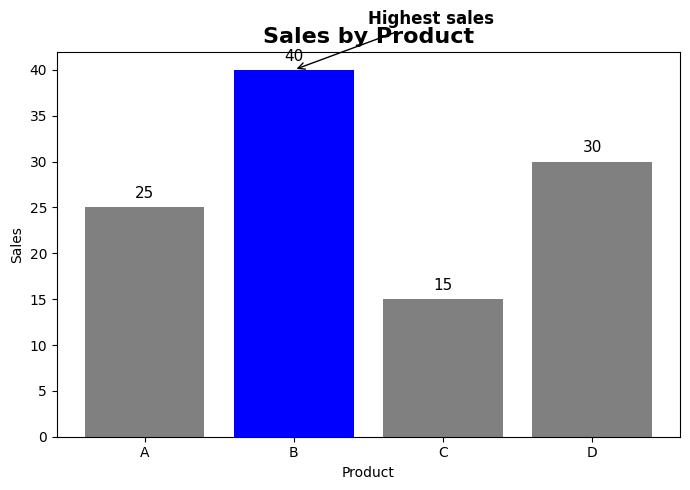

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.DataFrame({
    "Product": ["A", "B", "C", "D"],
    "Sales": [25, 40, 15, 30]
})

colors = ['gray', 'blue', 'gray', 'gray']

plt.figure(figsize=(7,5))
bars = plt.bar(data['Product'], data['Sales'], color=colors)

plt.title("Sales by Product", fontsize=16, fontweight='bold')
plt.ylabel("Sales")
plt.xlabel("Product")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height}', ha='center', fontsize=11)

plt.annotate(
    'Highest sales', 
    xy=(1, data.loc[data['Product']=='B', 'Sales'].values[0]), 
    xytext=(1.5, 45),
    arrowprops=dict(facecolor='black', arrowstyle='->'),
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.show()